# Stage 4 — Hiperparametrización con Optuna

**Objetivo:** Optimizar los 5 modelos baseline usando Optuna y elegir el mejor candidato final.

**Métrica objetivo:** F1 de clase 0 (insatisfechos) — porque el error más costoso es no detectar un cliente que se va a ir.

**Regla de oro:** El test set NO se toca hasta haber elegido el modelo final.

## 1. Imports y configuración

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # silenciar logs por trial
from optuna.pruners import MedianPruner

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, KFold
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score, make_scorer, accuracy_score
from sklearn.calibration import CalibratedClassifierCV
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import LinearSVC

SEED       = 2357
N_TRIALS   = 100    # trials por modelo — aumentar si tienes tiempo
TARGET_COL = 'satisfecho'   # ← ajusta si es necesario
POS_LABEL  = 0     # clase que nos importa: insatisfecho

N_FOLDS = 5

print('Librerías cargadas ✓')
print(f'Optuna versión: {optuna.__version__}')

Librerías cargadas ✓
Optuna versión: 4.9.0


## 2. Carga de datos

In [2]:
DATA = "data/master/"
# ── Ajusta las rutas a tu estructura de carpetas ──
X_TRAIN_PATH = f'{DATA}X_train.csv'
X_VAL_PATH   = f'{DATA}X_val.csv'
X_TEST_PATH  = f'{DATA}X_backtest.csv'
Y_TRAIN_PATH = f'{DATA}y_train.csv'
Y_VAL_PATH   = f'{DATA}y_val.csv'
Y_TEST_PATH  = f'{DATA}y_backtest.csv'

X_train = pd.read_csv(X_TRAIN_PATH)
X_val   = pd.read_csv(X_VAL_PATH)
X_test  = pd.read_csv(X_TEST_PATH)

y_train = pd.read_csv(Y_TRAIN_PATH)
y_val   = pd.read_csv(Y_VAL_PATH)
y_test  = pd.read_csv(Y_TEST_PATH)

# Ratio para scale_pos_weight en XGBoost/LightGBM
# = n_negativos / n_positivos  (negativos = insatisfechos = clase 0)
neg = int(np.sum(y_train == 0))
pos = int(np.sum(y_train == 1))
SPW = round(pos / neg, 4)   # scale_pos_weight penaliza la clase 1 (satisfecho)
                            # para que el modelo preste más atención al 0

print(f'Train: {X_train.shape} | insatisfechos: {(y_train==0).mean().item():.2%}')
print(f'Val:   {X_val.shape}   | insatisfechos: {(y_val==0).mean().item():.2%}')
print(f'scale_pos_weight para boosting: {SPW}')

Train: (43294, 25) | insatisfechos: 20.64%
Val:   (20374, 25)   | insatisfechos: 27.31%
scale_pos_weight para boosting: 3.8438


## 3. Función de evaluación común

Centraliza el cálculo de métricas para no repetir código en cada objective.

In [12]:
def metricas(y_true, y_pred, y_proba):
    """Devuelve dict de métricas. pos_label=0 porque nos importan los insatisfechos."""
    auc = roc_auc_score(y_true, y_proba)
    return {
        'f1_0'     : f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        'recall_0' : recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        'prec_0'   : precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        'f1_1'     : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_1' : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'prec_1'   : precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_macro' : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'accuracy' : accuracy_score(y_true, y_pred),
        'auc'      : auc,
        'gini'     : 2 * auc -1,
    }

## 4. Objective functions

Cada función define el espacio de búsqueda para un modelo.
Optuna llama a estas funciones `N_TRIALS` veces con distintos parámetros y maximiza el valor retornado.

**Patrón:**
```
trial.suggest_float('param', low, high)        # continuo
trial.suggest_int('param', low, high)          # entero
trial.suggest_categorical('param', [a, b, c])  # categórico
```

In [ ]:
# ── Logistic Regression ────────────────────────────────────────────────────── sin 5f cv
def objective_lr(trial):
    params = {
        'C'           : trial.suggest_float('C', 1e-3, 10, log=True),
        'solver'      : trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'max_iter'    : 1000,
        'random_state': SEED,
    }
    model = LogisticRegression(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# ── Random Forest ─────────────────────────────────────────────────────────────
def objective_rf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'class_weight'     : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state'     : SEED,
        'n_jobs'           : -2,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# ── Hist Gradient Boosting ---------──────────────────────────────────────────
def objective_hgb(trial):
    params = {
        'max_iter'          : trial.suggest_int('max_iter', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_leaf_nodes'    : trial.suggest_int('max_leaf_nodes', 15, 255),        
        'l2_regularization' : trial.suggest_float('l2_regularization', 1e-10, 1.0, log=True),
        'class_weight'      : trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state'      : SEED,
    }    

    model = HistGradientBoostingClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# ── CatBoost ──────────────────────────────────────────────────────────────────
def objective_cb(trial):
    params = {
        'iterations'          : trial.suggest_int('iterations', 100, 1500),
        'depth'               : trial.suggest_int('depth', 2, 10),
        'learning_rate'       : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'bagging_temperature' : trial.suggest_float('bagging_temperature', 0.5, 1.0),        
        'colsample_bylevel'   : trial.suggest_float('colsample_bylevel', 0.5, 1.0), # eliminar si se usa GPU
        'l2_leaf_reg'         : trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'auto_class_weights'  : trial.suggest_categorical('auto_class_weights', [None, 'Balanced']),
        'od_type'             : trial.suggest_categorical("od_type", ['IncToDec', 'Iter']),
        'od_wait'             : trial.suggest_int("od_wait", 10, 50),
        'random_state'        : SEED,        
        'verbose'             : False,
        'task_type'           : 'CPU', # GPU si filas > 100k
        'devices'             : '0-4', # 0 si se usa GPU
        'loss_function'       : 'Logloss',
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# ── LightGBM ──────────────────────────────────────────────────────────────────
def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 2, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight'     : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state'     : SEED,
        'verbosity'        : -1,
        'n_jobs'           : -2,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)


# --- LinearSVC ----------------------------------------------------------------
def objective_lsvm(trial):
    params = {
        'C'            : trial.suggest_float('C', 1e-3, 100.0, log=True),
        'loss'         : trial.suggest_categorical('loss', ['hinge', 'squared_hinge']),
        'penalty'      : trial.suggest_categorical('penalty', ['l2']),  # l1 requiere dual=False
        'dual'         : 'auto',
        'tol'          : trial.suggest_float('tol', 1e-5, 1e-1, log=True),
        'max_iter'     : 10000,  # Alto para asegurar convergencia
        'class_weight' : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state' : SEED,
    }
    
    # Si elige hinge, no se puede calibrar con sigmoid de forma estable
    # (CalibratedClassifierCV funciona mejor con squared_hinge o con isotonic)
    calibration_method = trial.suggest_categorical('calibration_method', ['sigmoid', 'isotonic'])
    
    base_model = LinearSVC(**params)
    
    # CalibratedClassifierCV para obtener predict_proba
    model = CalibratedClassifierCV(
        base_model,
        method=calibration_method,
        cv=5,  # 3-fold para no ser tan lento; 5 es más robusto
        n_jobs=-2,
    )
    
    model.fit(X_train, y_train)
    
    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)

# --- SGDClassifier ----------------------------------------------------------
def objective_sgd(trial):
    params = {
        'loss'          : trial.suggest_categorical('loss', ['log_loss', 'modified_huber', 'hinge']),
        'penalty'       : trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'alpha'         : trial.suggest_float('alpha', 1e-5, 1.0, log=True),
        'learning_rate' : trial.suggest_categorical('learning_rate', ['optimal', 'constant', 'invscaling', 'adaptive']),
        'eta0'          : trial.suggest_float('eta0', 1e-4, 0.1, log=True) if trial.params.get('learning_rate') != 'optimal' else 0.01,
        'max_iter'      : 2000,
        'tol'           : trial.suggest_float('tol', 1e-5, 1e-2, log=True),
        'class_weight'  : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'n_jobs'        : -2,
        'random_state'  : SEED,
    }
    
    # Si elige elasticnet, añadir l1_ratio
    if params['penalty'] == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    # Si learning_rate es 'optimal', eta0 no se usa pero sklearn lo acepta
    # Lo limpiamos para evitar warnings
    if params['learning_rate'] == 'optimal':
        params.pop('eta0', None)
    
    model = SGDClassifier(**params)
    model.fit(X_train, y_train)
    
    # SGD con log_loss y modified_huber tiene predict_proba
    # hinge no tiene, usamos decision_function
    if params['loss'] in ['log_loss', 'modified_huber']:
        proba = model.predict_proba(X_val)[:, 1]
    else:
        # Para hinge, normalizamos decision_function a [0,1] aproximadamente
        decision = model.decision_function(X_val)
        proba = 1 / (1 + np.exp(-decision))  # sigmoid manual
    
    pred = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)

# --- ExtraTreesClassifier -----------------------------------------------------
def objective_et(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 50, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 50) if trial.suggest_categorical('use_max_depth', [True, False]) else None,
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features'      : trial.suggest_categorical('max_features', ['sqrt', 'log2', None, 0.3, 0.5, 0.7]),
        'bootstrap'         : trial.suggest_categorical('bootstrap', [False, True]),
        'class_weight'      : trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
        'criterion'         : trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'n_jobs'            : -2,
        'random_state'      : SEED,
    }
    
    # Si max_depth no se usa, eliminarlo
    if not params.get('use_max_depth', True):
        params.pop('max_depth', None)
    params.pop('use_max_depth', None)  # Limpiar flag interno
    
    # Si bootstrap=False, class_weight='balanced_subsample' no tiene sentido
    if not params['bootstrap'] and params['class_weight'] == 'balanced_subsample':
        params['class_weight'] = 'balanced'
    
    model = ExtraTreesClassifier(**params)
    model.fit(X_train, y_train)
    
    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return f1_score(y_val, pred, pos_label=POS_LABEL, zero_division=0)

print('Objective functions definidas ✓')

Objective functions definidas ✓


con 5-f cv

In [6]:
# ── Threshold tuning: encuentra el mejor umbral para F1(clase 0) ─────────────
def find_best_threshold(y_true, y_proba, thresholds=None):
    """
    Busca el umbral que maximiza F1 para la clase positiva (insatisfechos = 0).
    """
    if thresholds is None:
        thresholds = np.arange(0.1, 0.9, 0.02)
    
    best_thresh = 0.5
    best_f1 = 0.0
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    return best_thresh, best_f1


# ── Helper genérico con CV + threshold tuning + pruning ─────────────────────
def _cv_evaluate(trial, model_class, params, X_tr, y_tr, X_val, y_val,
                 pos_label, seed, n_splits=5, fit_kwargs=None,
                 use_threshold_tuning=True, predict_proba=True):
    """
    Ejecuta CV interna con pruning, threshold tuning opcional, y evaluación final.
    Retorna: (mean_cv_f1_0, dict_metricas_val, best_threshold)
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    cv_f1_scores = []
    fit_kwargs = fit_kwargs or {}
    
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_tr, y_tr)):
        X_fold_tr, X_fold_va = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        y_fold_tr, y_fold_va = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]
        
        model = model_class(**params)
        model.fit(X_fold_tr, y_fold_tr, **fit_kwargs)
        
        if predict_proba:
            fold_proba = model.predict_proba(X_fold_va)[:, 1]
        else:
            # Para modelos sin predict_proba, usamos decision_function normalizado
            fold_decision = model.decision_function(X_fold_va)
            fold_proba = 1 / (1 + np.exp(-fold_decision))
        
        # Threshold tuning en cada fold
        if use_threshold_tuning:
            _, _ = find_best_threshold(y_fold_va, fold_proba)  # solo para consistencia
            # Usamos 0.5 en CV para estabilidad, el tuning se hace en val final
            fold_pred = (fold_proba >= 0.5).astype(int)
        else:
            fold_pred = (fold_proba >= 0.5).astype(int)
        
        fold_f1 = f1_score(y_fold_va, fold_pred, pos_label=pos_label, zero_division=0)
        cv_f1_scores.append(fold_f1)
        
        # ── PRUNING: reportar F1 de cada fold ──────────────────────────────
        trial.report(fold_f1, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    # ── Evaluación final sobre VAL (con threshold tuning) ──────────────────
    final_model = model_class(**params)
    final_model.fit(X_tr, y_tr, **fit_kwargs)
    
    if predict_proba:
        val_proba = final_model.predict_proba(X_val)[:, 1]
    else:
        val_decision = final_model.decision_function(X_val)
        val_proba = 1 / (1 + np.exp(-val_decision))
    
    # Threshold tuning en val
    best_thresh, _ = find_best_threshold(y_val, val_proba)
    val_pred = (val_proba >= best_thresh).astype(int)
    
    # Calcular métricas con tu función
    metrics = metricas(y_val, val_pred, val_proba)
    metrics['threshold'] = best_thresh  # guardar el umbral óptimo encontrado
    
    return np.mean(cv_f1_scores), metrics, best_thresh

In [9]:
# con 5-f cv

# ── Logistic Regression ───────────────────────────────────────────────────────
def objective_lr(trial):
    params = {
        'C'           : trial.suggest_float('C', 1e-3, 10, log=True),
        'solver'      : trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'max_iter'    : 1000,
        'random_state': SEED,
    }
    
    cv_f1, metrics, thresh = _cv_evaluate(
        trial, LogisticRegression, params, X_train, y_train, X_val, y_val,
        POS_LABEL, SEED
    )
    
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    
    return cv_f1


# ── Random Forest ─────────────────────────────────────────────────────────────
def objective_rf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'class_weight'     : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state'     : SEED,
        'n_jobs'           : -2,
    }
    
    cv_f1, metrics, thresh = _cv_evaluate(
        trial, RandomForestClassifier, params, X_train, y_train, X_val, y_val,
        POS_LABEL, SEED
    )
    
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    
    return cv_f1


# ── Hist Gradient Boosting ────────────────────────────────────────────────────
def objective_hgb(trial):
    params = {
        'max_iter'          : trial.suggest_int('max_iter', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_leaf_nodes'    : trial.suggest_int('max_leaf_nodes', 15, 255),        
        'l2_regularization' : trial.suggest_float('l2_regularization', 1e-10, 1.0, log=True),
        'class_weight'      : trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state'      : SEED,
    }    
    
    cv_f1, metrics, thresh = _cv_evaluate(
        trial, HistGradientBoostingClassifier, params, X_train, y_train, X_val, y_val,
        POS_LABEL, SEED
    )
    
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    
    return cv_f1


# ── CatBoost ──────────────────────────────────────────────────────────────────
def objective_cb(trial):
    params = {
        'iterations'          : trial.suggest_int('iterations', 100, 1500),
        'depth'               : trial.suggest_int('depth', 2, 10),
        'learning_rate'       : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'bagging_temperature' : trial.suggest_float('bagging_temperature', 0.5, 1.0),        
        'colsample_bylevel'   : trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'l2_leaf_reg'         : trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'auto_class_weights'  : trial.suggest_categorical('auto_class_weights', [None, 'Balanced']),
        'od_type'             : trial.suggest_categorical("od_type", ['IncToDec', 'Iter']),
        'od_wait'             : trial.suggest_int("od_wait", 10, 50),
        'random_state'        : SEED,        
        'verbose'             : False,
        'task_type'           : 'CPU',
        'devices'             : '0-4',
        'loss_function'       : 'Logloss',
    }
    
    # CatBoost necesita early_stopping manual
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_f1_scores = []
    
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold_tr, X_fold_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_fold_tr, y_fold_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(X_fold_tr, y_fold_tr, eval_set=(X_fold_va, y_fold_va),
                  early_stopping_rounds=50, verbose=False)
        
        fold_proba = model.predict_proba(X_fold_va)[:, 1]
        fold_pred = (fold_proba >= 0.5).astype(int)
        fold_f1 = f1_score(y_fold_va, fold_pred, pos_label=POS_LABEL, zero_division=0)
        cv_f1_scores.append(fold_f1)
        
        # Pruning
        trial.report(fold_f1, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    # Evaluación final
    final_model = CatBoostClassifier(**params)
    final_model.fit(X_train, y_train, eval_set=(X_val, y_val),
                    early_stopping_rounds=50, verbose=False)
    
    val_proba = final_model.predict_proba(X_val)[:, 1]
    best_thresh, _ = find_best_threshold(y_val, val_proba)
    val_pred = (val_proba >= best_thresh).astype(int)
    
    metrics = metricas(y_val, val_pred, val_proba)
    metrics['threshold'] = best_thresh
    
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    
    return np.mean(cv_f1_scores)


# ── LightGBM ──────────────────────────────────────────────────────────────────
def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 2, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight'     : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state'     : SEED,
        'verbosity'        : -1,
        'n_jobs'           : -2,
    }
    
    cv_f1, metrics, thresh = _cv_evaluate(
        trial, LGBMClassifier, params, X_train, y_train, X_val, y_val,
        POS_LABEL, SEED
    )
    
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    
    return cv_f1


# ── LinearSVM ─────────────────────────────────────────────────────────────────
def objective_lsvm(trial):
    params = {
        'C'            : trial.suggest_float('C', 1e-3, 100.0, log=True),
        'loss'         : trial.suggest_categorical('loss', ['hinge', 'squared_hinge']),
        'penalty'      : 'l2',
        'dual'         : 'auto',
        'tol'          : trial.suggest_float('tol', 1e-5, 1e-1, log=True),
        'max_iter'     : 10000,
        'class_weight' : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state' : SEED,
    }
    
    calibration_method = trial.suggest_categorical('calibration_method', ['sigmoid', 'isotonic'])
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_f1_scores = []
    
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold_tr, X_fold_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_fold_tr, y_fold_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        
        base = LinearSVC(**params)
        model = CalibratedClassifierCV(base, method=calibration_method, cv=3, n_jobs=-2)
        model.fit(X_fold_tr, y_fold_tr)
        
        fold_proba = model.predict_proba(X_fold_va)[:, 1]
        fold_pred = (fold_proba >= 0.5).astype(int)
        fold_f1 = f1_score(y_fold_va, fold_pred, pos_label=POS_LABEL, zero_division=0)
        cv_f1_scores.append(fold_f1)
        
        trial.report(fold_f1, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    # Final
    final_base = LinearSVC(**params)
    final_model = CalibratedClassifierCV(final_base, method=calibration_method, cv=5, n_jobs=-2)
    final_model.fit(X_train, y_train)
    
    val_proba = final_model.predict_proba(X_val)[:, 1]
    best_thresh, _ = find_best_threshold(y_val, val_proba)
    val_pred = (val_proba >= best_thresh).astype(int)
    
    metrics = metricas(y_val, val_pred, val_proba)
    metrics['threshold'] = best_thresh
    
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    
    return np.mean(cv_f1_scores)


# ── SGD Classifier ────────────────────────────────────────────────────────────
def objective_sgd(trial):
    params = {
        'loss'          : trial.suggest_categorical('loss', ['log_loss', 'modified_huber', 'hinge']),
        'penalty'       : trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'alpha'         : trial.suggest_float('alpha', 1e-5, 1.0, log=True),
        'learning_rate' : trial.suggest_categorical('learning_rate', ['optimal', 'constant', 'invscaling', 'adaptive']),
        'max_iter'      : 2000,
        'tol'           : trial.suggest_float('tol', 1e-5, 1e-2, log=True),
        'class_weight'  : trial.suggest_categorical('class_weight', [None, 'balanced']),
        'n_jobs'        : -2,
        'random_state'  : SEED,
    }
    
    if params['learning_rate'] != 'optimal':
        params['eta0'] = trial.suggest_float('eta0', 1e-4, 0.1, log=True)
    
    if params['penalty'] == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    # Wrapper para manejar predict_proba vs decision_function
    class SGDWrapper:
        def __init__(self, params):
            self.model = SGDClassifier(**params)
            self.loss = params['loss']
        
        def fit(self, X, y):
            self.model.fit(X, y)
            return self
        
        def predict_proba(self, X):
            if self.loss in ['log_loss', 'modified_huber']:
                return self.model.predict_proba(X)
            else:
                decision = self.model.decision_function(X)
                proba = 1 / (1 + np.exp(-decision))
                # Convertir a formato [P(clase0), P(clase1)] asumiendo binario
                return np.column_stack([1 - proba, proba])
        
        def predict(self, X):
            return self.model.predict(X)
    
    cv_f1, metrics, thresh = _cv_evaluate(
        trial, SGDWrapper, {'params': params}, X_train, y_train, X_val, y_val,
        POS_LABEL, SEED
    )
    
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    
    return cv_f1


# ── Extra Trees ─────────────────────────────────────────────────────────────────
def objective_et(trial):
    use_max_depth = trial.suggest_categorical('use_max_depth', [True, False])
    
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 50, 500),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features'      : trial.suggest_categorical('max_features', ['sqrt', 'log2', None, 0.3, 0.5, 0.7]),
        'bootstrap'         : trial.suggest_categorical('bootstrap', [False, True]),
        'class_weight'      : trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
        'criterion'         : trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'n_jobs'            : -2,
        'random_state'      : SEED,
    }
    
    if use_max_depth:
        params['max_depth'] = trial.suggest_int('max_depth', 3, 50)
    
    if not params['bootstrap'] and params['class_weight'] == 'balanced_subsample':
        params['class_weight'] = 'balanced'
    
    cv_f1, metrics, thresh = _cv_evaluate(
        trial, ExtraTreesClassifier, params, X_train, y_train, X_val, y_val,
        POS_LABEL, SEED
    )
    
    for k, v in metrics.items():
        trial.set_user_attr(k, v)
    
    return cv_f1


print('Objective functions con cv definidas ✓')

Objective functions con cv definidas ✓


## 5. Ejecución de estudios Optuna

Cada modelo corre un `study` independiente. Optuna usa el algoritmo TPE (Tree-structured Parzen Estimator) por defecto — aprende qué zonas del espacio de parámetros son prometedoras a medida que avanza.

In [ ]:
import time # sin cv

ESTUDIOS = {
    'Logistic Regression'    : objective_lr,
    'Random Forest'          : objective_rf,
    'Hist Gradient Boosting' : objective_hgb,
    'CatBoost'               : objective_cb,
    'LightGBM'               : objective_lgbm,
    'LinearSVM'              : objective_lsvm,
    'SGD Classifier'         : objective_sgd,
    'Extra Trees'            : objective_et,
}

estudios_completados = {}   # guardamos los study objects para análisis posterior

for nombre, objective in ESTUDIOS.items():
    print(f'\n▶ Optimizando {nombre} ({N_TRIALS} trials)...')
    t0 = time.time()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        study_name=nombre,
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    estudios_completados[nombre] = study
    elapsed = time.time() - t0
    print(f'  ✓ Mejor F1(clase 0): {study.best_value:.4f} | Tiempo: {elapsed:.0f}s')
    print(f'  Mejores params: {study.best_params}')

print('\n✓ Todos los estudios completados')


▶ Optimizando Logistic Regression (100 trials)...


Best trial: 92. Best value: 0.558025: 100%|██████████| 100/100 [00:58<00:00,  1.70it/s]


  ✓ Mejor F1(clase 0): 0.5580 | Tiempo: 59s
  Mejores params: {'C': 0.00470926704826181, 'solver': 'lbfgs', 'class_weight': 'balanced'}

▶ Optimizando Random Forest (100 trials)...


Best trial: 23. Best value: 0.576501: 100%|██████████| 100/100 [04:59<00:00,  2.99s/it]


  ✓ Mejor F1(clase 0): 0.5765 | Tiempo: 299s
  Mejores params: {'n_estimators': 440, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}

▶ Optimizando Hist Gradient Boosting (100 trials)...


...

  ✓ Mejor F1(clase 0): 0.5384 | Tiempo: 254s
  Mejores params: {'C': 0.011342678650178892, 'loss': 'squared_hinge', 'penalty': 'l2', 'tol': 0.01858388810544286, 'class_weight': None, 'calibration_method': 'sigmoid'}

▶ Optimizando SGD Classifier (100 trials)...


Best trial: 61. Best value: 0.578625: 100%|██████████| 100/100 [00:52<00:00,  1.91it/s]


  ✓ Mejor F1(clase 0): 0.5786 | Tiempo: 52s
  Mejores params: {'loss': 'hinge', 'penalty': 'l1', 'alpha': 0.00010749820927645877, 'learning_rate': 'constant', 'eta0': 0.004656297949239907, 'tol': 0.006749956165626216, 'class_weight': 'balanced'}

▶ Optimizando Extra Trees (100 trials)...


Best trial: 91. Best value: 0.581402: 100%|██████████| 100/100 [03:02<00:00,  1.82s/it]

  ✓ Mejor F1(clase 0): 0.5814 | Tiempo: 182s
  Mejores params: {'n_estimators': 439, 'use_max_depth': True, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 30, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample', 'criterion': 'log_loss'}

✓ Todos los estudios completados


In [10]:
import time # con cv

ESTUDIOS = {
    'Logistic Regression'    : objective_lr,
    'Random Forest'          : objective_rf,
    'Hist Gradient Boosting' : objective_hgb,
    'CatBoost'               : objective_cb,
    'LightGBM'               : objective_lgbm,
    'LinearSVM'              : objective_lsvm,
    'SGD Classifier'         : objective_sgd,
    'Extra Trees'            : objective_et,
}

estudios_completados = {}

for nombre, objective in ESTUDIOS.items():
    print(f'\n▶ Optimizando {nombre} ({N_TRIALS} trials)...')
    t0 = time.time()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        study_name=nombre,
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),  # ← PRUNING
    )
    
    try:
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    except Exception as e:
        print(f"  ⚠ Error en {nombre}: {e}")
        continue

    estudios_completados[nombre] = study
    elapsed = time.time() - t0
    
    best = study.best_trial
    print(f'  ✓ Mejor CV F1(clase 0): {study.best_value:.4f} | Tiempo: {elapsed:.0f}s')
    print(f'  Val F1_0: {best.user_attrs["f1_0"]:.4f} | '
          f'Recall_0: {best.user_attrs["recall_0"]:.4f} | '
          f'Prec_0: {best.user_attrs["prec_0"]:.4f} | '
          f'Umbral: {best.user_attrs["threshold"]:.2f}')
    print(f'  Mejores params: {study.best_params}')

print('\n✓ Todos los estudios completados')


▶ Optimizando Logistic Regression (100 trials)...


Best trial: 1. Best value: 0.420704: 100%|██████████| 100/100 [10:06<00:00,  6.06s/it]


  ✓ Mejor CV F1(clase 0): 0.4207 | Tiempo: 606s
  Val F1_0: 0.5772 | Recall_0: 0.5517 | Prec_0: 0.6053 | Umbral: 0.42
  Mejores params: {'C': 5.757265123512944, 'solver': 'saga', 'class_weight': 'balanced'}

▶ Optimizando Random Forest (100 trials)...


Best trial: 19. Best value: 0.420345: 100%|██████████| 100/100 [19:32<00:00, 11.72s/it]


  ✓ Mejor CV F1(clase 0): 0.4203 | Tiempo: 1172s
  Val F1_0: 0.5753 | Recall_0: 0.5657 | Prec_0: 0.5852 | Umbral: 0.46
  Mejores params: {'n_estimators': 172, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced'}

▶ Optimizando Hist Gradient Boosting (100 trials)...


...

  ✓ Mejor CV F1(clase 0): 0.3460 | Tiempo: 12292s
  Val F1_0: 0.5573 | Recall_0: 0.4749 | Prec_0: 0.6742 | Umbral: 0.80
  Mejores params: {'C': 60.30514883339267, 'loss': 'hinge', 'tol': 0.0009237817280975728, 'class_weight': None, 'calibration_method': 'isotonic'}

▶ Optimizando SGD Classifier (100 trials)...


Best trial: 75. Best value: 0.421351: 100%|██████████| 100/100 [04:27<00:00,  2.68s/it]


  ✓ Mejor CV F1(clase 0): 0.4214 | Tiempo: 268s
  Val F1_0: 0.5775 | Recall_0: 0.5475 | Prec_0: 0.6109 | Umbral: 0.42
  Mejores params: {'loss': 'log_loss', 'penalty': 'l1', 'alpha': 0.001851127227811134, 'learning_rate': 'adaptive', 'tol': 0.0023514563546357644, 'class_weight': 'balanced', 'eta0': 0.01887186123031264}

▶ Optimizando Extra Trees (100 trials)...


Best trial: 15. Best value: 0.422971: 100%|██████████| 100/100 [13:52<00:00,  8.32s/it]

  ✓ Mejor CV F1(clase 0): 0.4230 | Tiempo: 832s
  Val F1_0: 0.5807 | Recall_0: 0.5378 | Prec_0: 0.6309 | Umbral: 0.42
  Mejores params: {'use_max_depth': True, 'n_estimators': 305, 'min_samples_split': 42, 'min_samples_leaf': 26, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 34}

✓ Todos los estudios completados


In [ ]:
rows = []
for nombre, study in estudios_completados.items():
    best = study.best_trial
    rows.append({
        'Modelo': nombre,
        'CV_F1_0': study.best_value,
        'Val_F1_0': best.user_attrs['f1_0'],
        'Val_Recall_0': best.user_attrs['recall_0'],
        'Val_Prec_0': best.user_attrs['prec_0'],
        'Val_F1_Macro': best.user_attrs['f1_macro'],
        'Val_Accuracy': best.user_attrs['accuracy'],
        'Val_AUC': best.user_attrs['auc'],
        'Val_Gini': best.user_attrs['gini'],
        'Umbral': best.user_attrs['threshold'],
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                Modelo  CV_F1_0  Val_F1_0  Val_Recall_0  Val_Prec_0  Val_F1_Macro  Val_Accuracy  Val_AUC  Val_Gini  Umbral
   Logistic Regression 0.420704  0.577230      0.551662    0.605284      0.713942      0.779278 0.763274  0.526549    0.42
         Random Forest 0.420345  0.575292      0.565678    0.585239      0.709670      0.771866 0.763483  0.526965    0.46
Hist Gradient Boosting 0.423119  0.577218      0.560467    0.595002      0.712309      0.775744 0.764450  0.528901    0.44
              CatBoost 0.425362  0.576284      0.545373    0.610910      0.714288      0.780946 0.764145  0.528290    0.42
              LightGBM 0.424830  0.576428      0.538724    0.619806      0.715618      0.783744 0.765815  0.531629    0.42
             LinearSVM 0.346029  0.557301      0.474933    0.674235      0.711494      0.793904 0.735894  0.471788    0.80
        SGD Classifier 0.421351  0.577466      0.547529    0.610866      0.714896      0.781143 0.762577  0.525155    0.42
           Extra

## 6. Re-entrenamiento con mejores parámetros y evaluación completa

In [13]:
def construir_modelo(nombre, params): 
    """Reconstruye el modelo con los parámetros óptimos encontrados por Optuna."""
    p = params.copy()

    if nombre == 'Logistic Regression':
        return LogisticRegression(**p, max_iter=1000, random_state=SEED), None

    if nombre == 'Random Forest':
        return RandomForestClassifier(**p, random_state=SEED, n_jobs=-2), None

    if nombre == 'Hist Gradient Boosting':
        use_weight = p.pop('use_sample_weight', False)
        return HistGradientBoostingClassifier(**p, random_state=SEED), use_weight

    if nombre == 'CatBoost':
        return CatBoostClassifier(**p, random_state=SEED, loss_function='Logloss',
                             verbose=False, thread_count=-1), None

    if nombre == 'LightGBM':
        return LGBMClassifier(**p, random_state=SEED, verbosity=-1, n_jobs=-2), None

    if nombre == 'LinearSVM':
        calibration_method = p.pop('calibration_method', 'sigmoid')
        base_model = LinearSVC(**p, random_state=SEED, max_iter=10000)
        model = CalibratedClassifierCV(
            base_model,
            method=calibration_method,
            cv=5,
            n_jobs=-2
        )
        return model, None  
    
    if nombre == 'SGD Classifier':
        # Limpiar eta0 si learning_rate es 'optimal'
        if p.get('learning_rate') == 'optimal':
            p.pop('eta0', None)
        if p.get('loss') not in ['log', 'log_loss', 'modified_huber']:
            p['loss'] = 'log_loss'
        return SGDClassifier(**p, random_state=SEED, n_jobs=-1), None
    
    if nombre == 'Extra Trees':
        # Limpiar flag interno de max_depth condicional
        p.pop('use_max_depth', None)
        return ExtraTreesClassifier(**p, random_state=SEED, n_jobs=-2), None
    
    else:
        raise ValueError(f"Modelo '{nombre}' no reconocido. Nombres válidos: Logistic Regression, Random Forest, Hist Gradient Boosting, CatBoost, LightGBM, LinearSVC, SGDClassifier, ExtraTrees")


resultados_optuna = []

for nombre, study in estudios_completados.items():
    print(f'Procesando modelo {nombre}...')
    best_params = study.best_params.copy()

    resultado = construir_modelo(nombre, best_params)

    if isinstance(resultado, tuple):
        model, use_weight = resultado
    else:
        model = resultado
        use_weight = False

    # Manejo especial de Hist Gradient Boosting por sample_weight
    if nombre == 'Hist Gradient Boosting':
        resultado = construir_modelo(nombre, best_params)
        model, use_weight = resultado
        sw = np.where(y_train.to_numpy().ravel() == POS_LABEL,
                      len(y_train) / (2 * (y_train == POS_LABEL).sum()),
                      len(y_train) / (2 * (y_train != POS_LABEL).sum()))
        sw = sw.ravel()
        model.fit(X_train, y_train, sample_weight=sw if use_weight else None)
    else:        
        model.fit(X_train, y_train)

    proba = model.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    m     = metricas(y_val, pred, proba)

    resultados_optuna.append({
        'Modelo'    : nombre,
        'F1(cls 0)' : round(m['f1_0'],     4),
        'Rec(cls 0)': round(m['recall_0'], 4),
        'Pre(cls 0)': round(m['prec_0'],   4),
        'F1(cls 1)' : round(m['f1_1'],     4),
        'Rec(cls 1)': round(m['recall_1'], 4),
        'Pre(cls 1)': round(m['prec_1'],   4),
        'F1 macro'  : round(m['f1_macro'], 4),
        'Accuracy'  : round(m['accuracy'], 4), 
        'AUC-ROC'   : round(m['auc'],      4),
        'Gini'      : round(m['gini'],     4),
        '_proba'    : proba,
        '_model'    : model,
        '_params'   : best_params,
    })

print('✓ Re-entrenamiento completado')

Procesando modelo Logistic Regression...
Procesando modelo Random Forest...
Procesando modelo Hist Gradient Boosting...
Procesando modelo CatBoost...
Procesando modelo LightGBM...
Procesando modelo LinearSVM...
Procesando modelo SGD Classifier...
Procesando modelo Extra Trees...
✓ Re-entrenamiento completado


## 7. Tabla de resultados post Optuna

In [14]:
cols = ['Modelo', 'F1(cls 0)', 'Rec(cls 0)', 'Pre(cls 0)', 'F1(cls 1)', 'Rec(cls 1)', 'Pre(cls 1)', 'F1 macro', 'Accuracy', 'AUC-ROC', 'Gini']
df_optuna = pd.DataFrame(resultados_optuna)[cols].sort_values('F1(cls 0)', ascending=False)

def highlight_best(s):
    if s.name == 'Modelo': return ['' for _ in s]
    is_best = s == s.max()
    return ['background-color: #002357; font-weight: bold' if v else '' for v in is_best]

print('Resultados post-Optuna (ordenados por F1 clase 0):')
df_optuna.style.apply(highlight_best).set_caption('Validación — métricas con parámetros óptimos')

Resultados post-Optuna (ordenados por F1 clase 0):


,Modelo,F1(cls 0),Rec(cls 0),Pre(cls 0),F1(cls 1),Rec(cls 1),Pre(cls 1),F1 macro,Accuracy,AUC-ROC,Gini
1,Random Forest,0.569300,0.620500,0.525900,0.817400,0.789800,0.847000,0.693400,0.743500,0.763500,0.527000
7,Extra Trees,0.569200,0.631400,0.518100,0.812700,0.779300,0.849100,0.690900,0.738900,0.766700,0.533500
4,LightGBM,0.564000,0.649200,0.498600,0.800000,0.754600,0.851300,0.682000,0.725800,0.765800,0.531600
2,Hist Gradient Boosting,0.563100,0.643100,0.500800,0.801900,0.759100,0.849900,0.682500,0.727400,0.764500,0.528900
6,SGD Classifier,0.559300,0.670800,0.479600,0.785300,0.726500,0.854500,0.672300,0.711300,0.762600,0.525200
0,Logistic Regression,0.557400,0.671900,0.476200,0.782700,0.722300,0.854200,0.670100,0.708600,0.763300,0.526500
3,CatBoost,0.549900,0.639500,0.482200,0.790400,0.742000,0.845600,0.670100,0.714000,0.752600,0.505100
5,LinearSVM,0.537200,0.420800,0.742300,0.874000,0.945100,0.812800,0.705600,0.801900,0.735900,0.471800


## 8. Curvas de optimización por modelo

Muestra cómo fue mejorando el F1(clase 0) a lo largo de los trials. Si la curva se aplana antes del trial 50, los parámetros están bien convergidos.

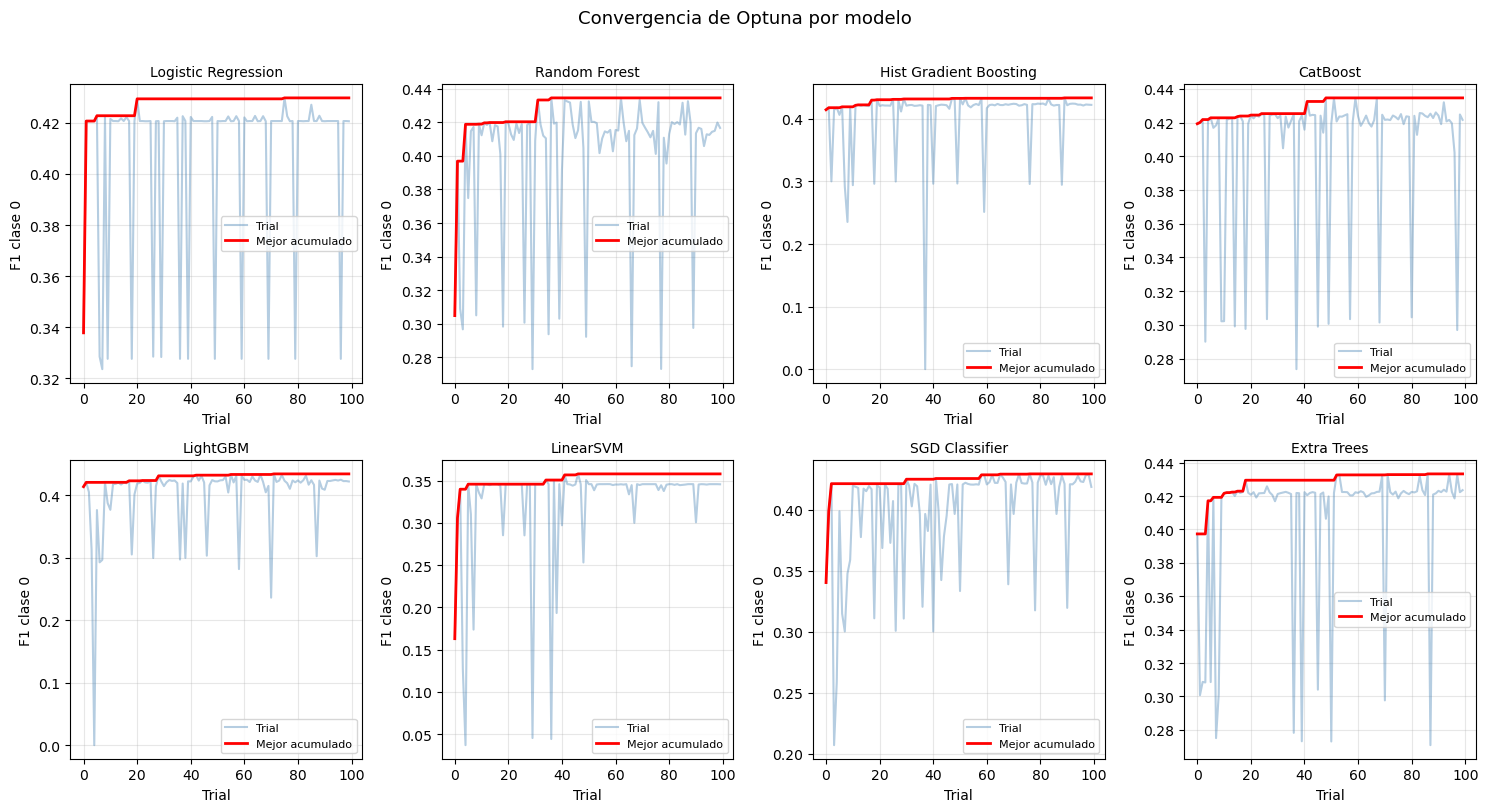

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, (nombre, study) in enumerate(estudios_completados.items()):
    valores = [t.value for t in study.trials if t.value is not None]
    mejor_acumulado = np.maximum.accumulate(valores)

    ax = axes[i]
    ax.plot(valores, alpha=0.4, color='steelblue', label='Trial')
    ax.plot(mejor_acumulado, color='red', lw=2, label='Mejor acumulado')
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Trial')
    ax.set_ylabel('F1 clase 0')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(len(estudios_completados), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Convergencia de Optuna por modelo', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('optuna_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Importancia de hiperparámetros (Optuna)

Optuna puede estimar qué hiperparámetros tuvieron más impacto en el resultado. Útil para saber dónde concentrar búsquedas futuras.

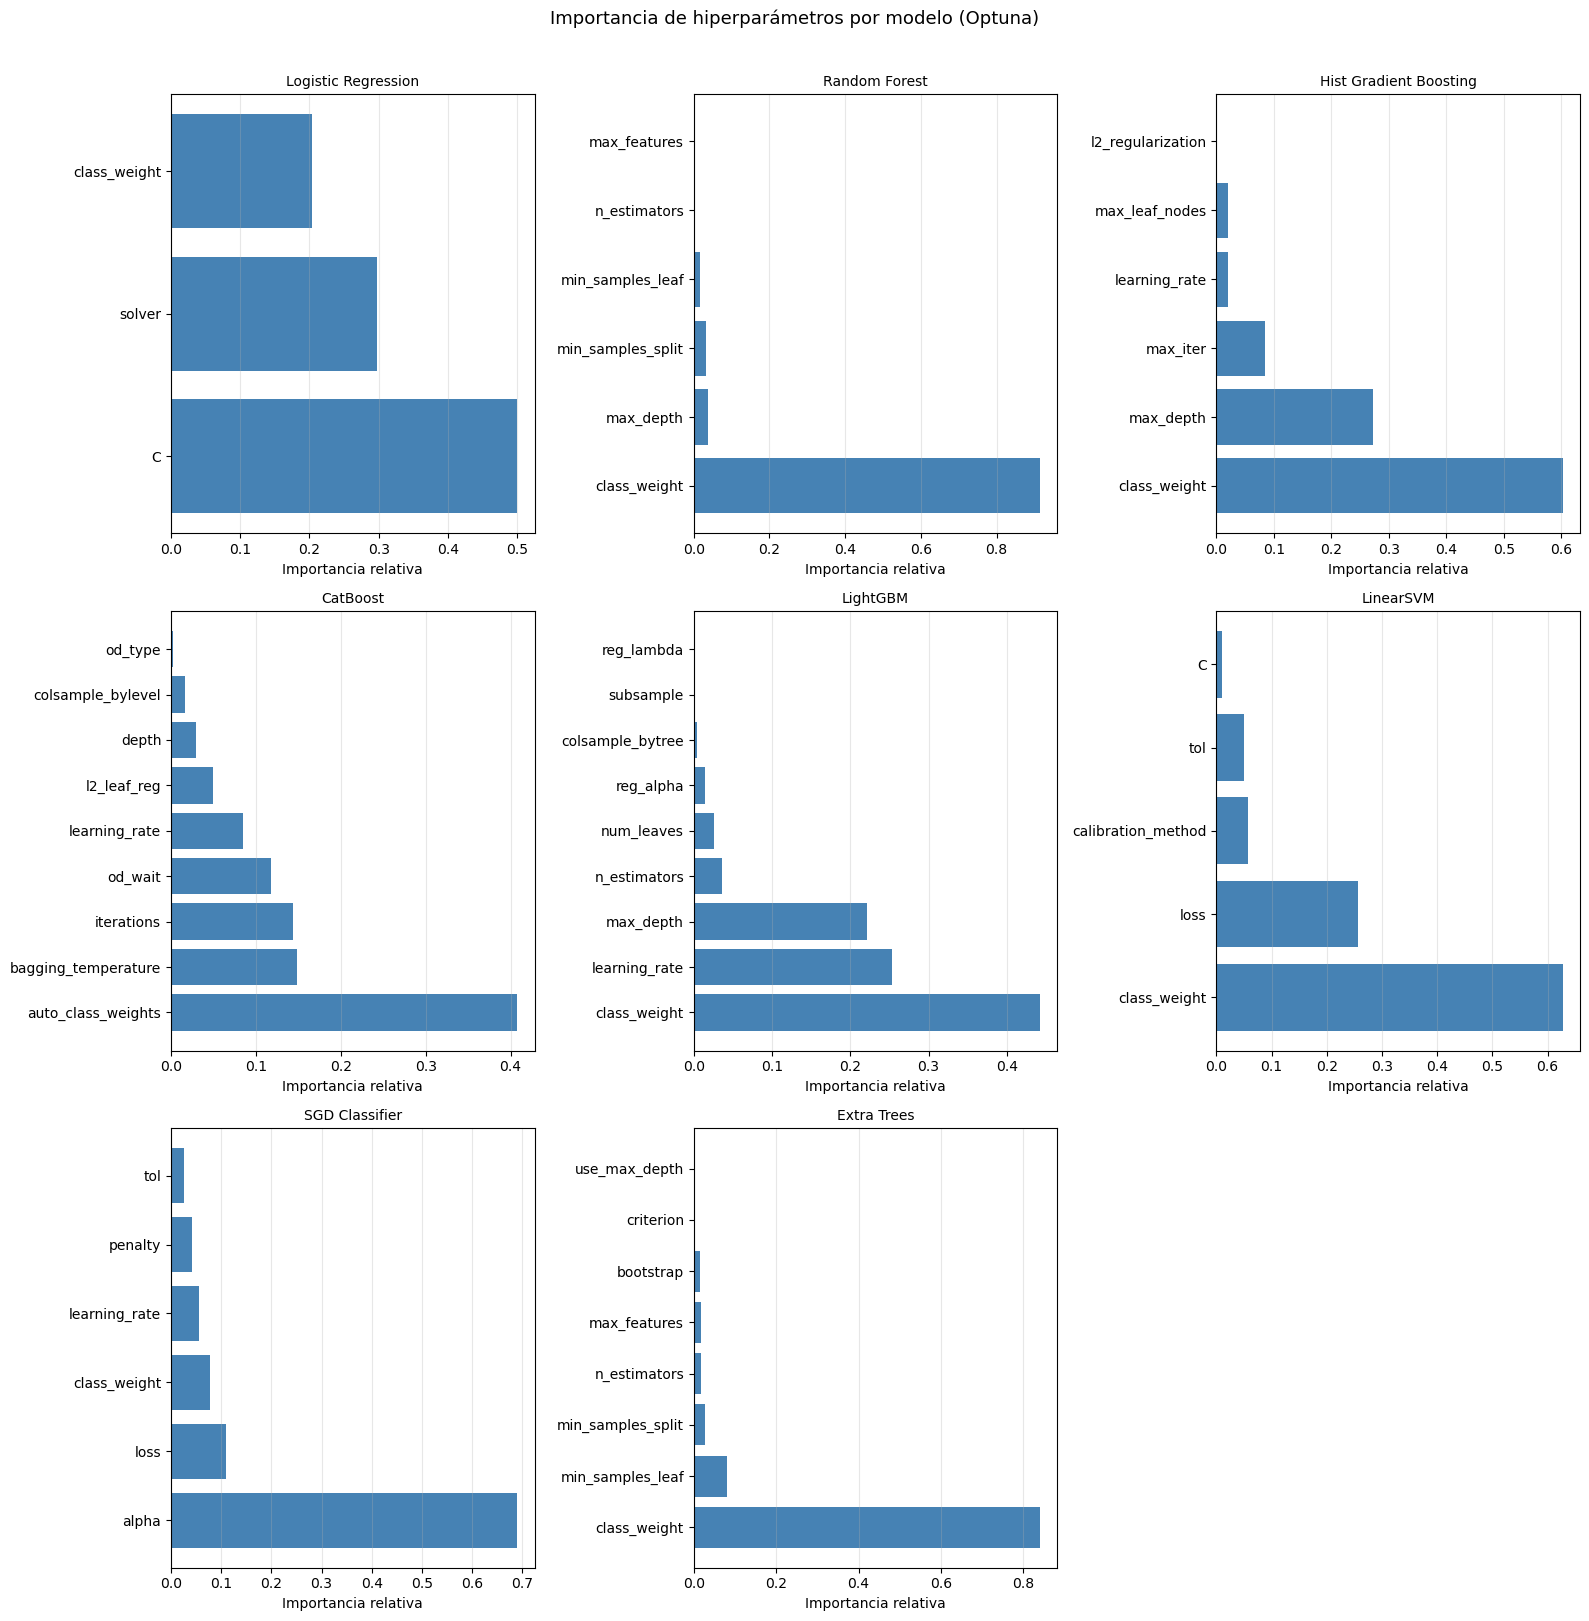

In [16]:
from optuna.importance import get_param_importances

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()

for i, (nombre, study) in enumerate(estudios_completados.items()):
    try:
        importancias = get_param_importances(study)
        params_names = list(importancias.keys())
        valores_imp  = list(importancias.values())

        ax = axes[i]
        ax.barh(params_names, valores_imp, color='steelblue')
        ax.set_title(f'{nombre}', fontsize=10)
        ax.set_xlabel('Importancia relativa')
        ax.grid(axis='x', alpha=0.3)
    except Exception as e:
        axes[i].set_title(f'{nombre}\n(no disponible: {e})', fontsize=9)

for j in range(len(estudios_completados), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Importancia de hiperparámetros por modelo (Optuna)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('optuna_param_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluación final en TEST del modelo ganador

⚠️ Solo correr esta celda una vez, después de haber elegido el modelo definitivo.

Modelo ganador: Random Forest
  F1(cls 0) val : 0.5693
  AUC-ROC   val : 0.7635
  Parámetros    : {'n_estimators': 172, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced'}

RESULTADOS EN TEST (conjunto no visto)
  F1 clase 0  : 0.3999
  Recall cls 0: 0.4127
  Prec   cls 0: 0.3880
  F1 macro    : 0.6296
  AUC-ROC     : 0.6794


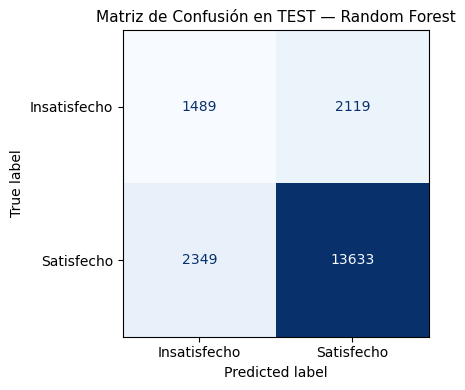


⚠️  El test set ya fue usado. No volver a modificar el modelo.


In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Modelo ganador = mayor F1 clase 0 en validación
ganador = max(resultados_optuna, key=lambda x: x['F1(cls 0)'])
print(f'Modelo ganador: {ganador["Modelo"]}')
print(f'  F1(cls 0) val : {ganador["F1(cls 0)"]}')
print(f'  AUC-ROC   val : {ganador["AUC-ROC"]}')
print(f'  Parámetros    : {ganador["_params"]}')
print()

# ── Evaluación en TEST ────────────────────────────────────────────────────────
model_final = ganador['_model']
proba_test  = model_final.predict_proba(X_test)[:, 1]
pred_test   = (proba_test >= 0.5).astype(int)
m_test      = metricas(y_test, pred_test, proba_test)

print('=' * 45)
print('RESULTADOS EN TEST (conjunto no visto)')
print('=' * 45)
print(f'  F1 clase 0  : {m_test["f1_0"]:.4f}')
print(f'  Recall cls 0: {m_test["recall_0"]:.4f}')
print(f'  Prec   cls 0: {m_test["prec_0"]:.4f}')
print(f'  F1 clase 1  : {m_test["f1_1"]:.4f}')
print(f'  Recall cls 1: {m_test["recall_1"]:.4f}')
print(f'  Prec   cls 1: {m_test["prec_1"]:.4f}')
print(f'  F1 macro    : {m_test["f1_macro"]:.4f}')
print(f'  Accuracy    : {m_test["accuracy"]:.4f}')
print(f'  AUC-ROC     : {m_test["auc"]:.4f}')
print(f'  Gini        : {m_test["gini"]:.4f}')

# Matriz de confusión en test
cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Insatisfecho', 'Satisfecho']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Matriz de Confusión en TEST — {ganador["Modelo"]}', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_test_final.png', dpi=150)
plt.show()

print('\n⚠️  El test set ya fue usado. No volver a modificar el modelo.')

Modelo ganador: Extra Trees
  F1(cls 0) val : 0.5692
  AUC-ROC   val : 0.7667
  Parámetros    : {'use_max_depth': True, 'n_estimators': 305, 'min_samples_split': 42, 'min_samples_leaf': 26, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 34}

RESULTADOS EN TEST (conjunto no visto)
  F1 clase 0  : 0.4077
  Recall cls 0: 0.4243
  Prec   cls 0: 0.3924
  F1 clase 1  : 0.8596
  Recall cls 1: 0.8516
  Prec   cls 1: 0.8676
  F1 macro    : 0.6336
  Accuracy    : 0.7729
  AUC-ROC     : 0.6820
  Gini        : 0.3640


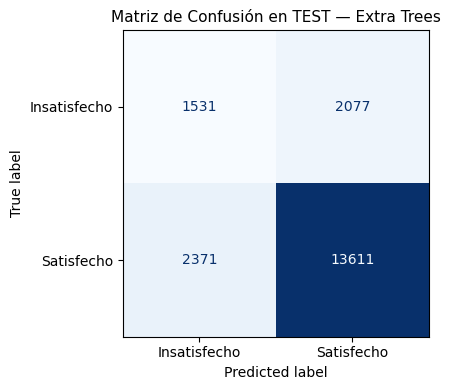


⚠️  El test set ya fue usado. No volver a modificar el modelo.


In [20]:
ganador = resultados_optuna[7]
print(f'Modelo ganador: {ganador["Modelo"]}')
print(f'  F1(cls 0) val : {ganador["F1(cls 0)"]}')
print(f'  AUC-ROC   val : {ganador["AUC-ROC"]}')
print(f'  Parámetros    : {ganador["_params"]}')
print()

# ── Evaluación en TEST ────────────────────────────────────────────────────────
model_final = ganador['_model']
proba_test  = model_final.predict_proba(X_test)[:, 1]
pred_test   = (proba_test >= 0.5).astype(int)
m_test      = metricas(y_test, pred_test, proba_test)

print('=' * 45)
print('RESULTADOS EN TEST (conjunto no visto)')
print('=' * 45)
print(f'  F1 clase 0  : {m_test["f1_0"]:.4f}')
print(f'  Recall cls 0: {m_test["recall_0"]:.4f}')
print(f'  Prec   cls 0: {m_test["prec_0"]:.4f}')
print(f'  F1 clase 1  : {m_test["f1_1"]:.4f}')
print(f'  Recall cls 1: {m_test["recall_1"]:.4f}')
print(f'  Prec   cls 1: {m_test["prec_1"]:.4f}')
print(f'  F1 macro    : {m_test["f1_macro"]:.4f}')
print(f'  Accuracy    : {m_test["accuracy"]:.4f}')
print(f'  AUC-ROC     : {m_test["auc"]:.4f}')
print(f'  Gini        : {m_test["gini"]:.4f}')

# Matriz de confusión en test
cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Insatisfecho', 'Satisfecho']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Matriz de Confusión en TEST — {ganador["Modelo"]}', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_test_final.png', dpi=150)
plt.show()

print('\n⚠️  El test set ya fue usado. No volver a modificar el modelo.')

In [28]:
from sklearn.ensemble import ExtraTreesClassifier

# Parámetros optimizados
params = {
    'n_estimators': 305,
    'min_samples_split': 42,
    'min_samples_leaf': 26,
    'max_features': 'sqrt',
    'bootstrap': False,
    'class_weight': 'balanced',
    'criterion': 'gini',
    'max_depth': 34 if True else None
}

# Entrenar con los parámetros
model = ExtraTreesClassifier(**params)
model.fit(X_test, pred_test)

# Obtener importancias
importancias = model.feature_importances_

# Mostrar con nombres de features
for feature, importance in zip(X_test.columns, importancias):
    print(f"{feature}: {importance}")

interaccion_retraso_items: 0.07494924066628048
delivery_delay_days: 0.05627806156235302
interaccion_precio_tarde: 0.022409533090530356
delay_ratio: 0.11637211240691828
actual_delivery_days: 0.08493610936852183
delivered_on_time: 0.09071692622750747
order_item_count: 0.054096127524511706
is_multi_item: 0.3390770963028093
unique_sellers: 0.008771479141286329
interaccion_entrega_flete: 0.05300203446990373
total_freight_value: 0.029766988791285694
dispatch_time_hours: 0.01983121972430697
te_product_category_name_english: 0.011839880051007142
promised_delivery_days: 0.00821053692001076
log_payment_value: 0.006315918003444233
freight_ratio: 0.0052913756655042846
product_volume_cm3: 0.001955043188041242
total_price: 0.0030930380909165744
product_height_cm: 0.0014974952689449927
product_weight_g: 0.00280336528821965
product_name_lenght: 0.0004953829133416148
product_width_cm: 0.000574363657089363
product_length_cm: 0.0009279497770038912
purchase_dayofweek: 0.0005432946282458765
seller_customer

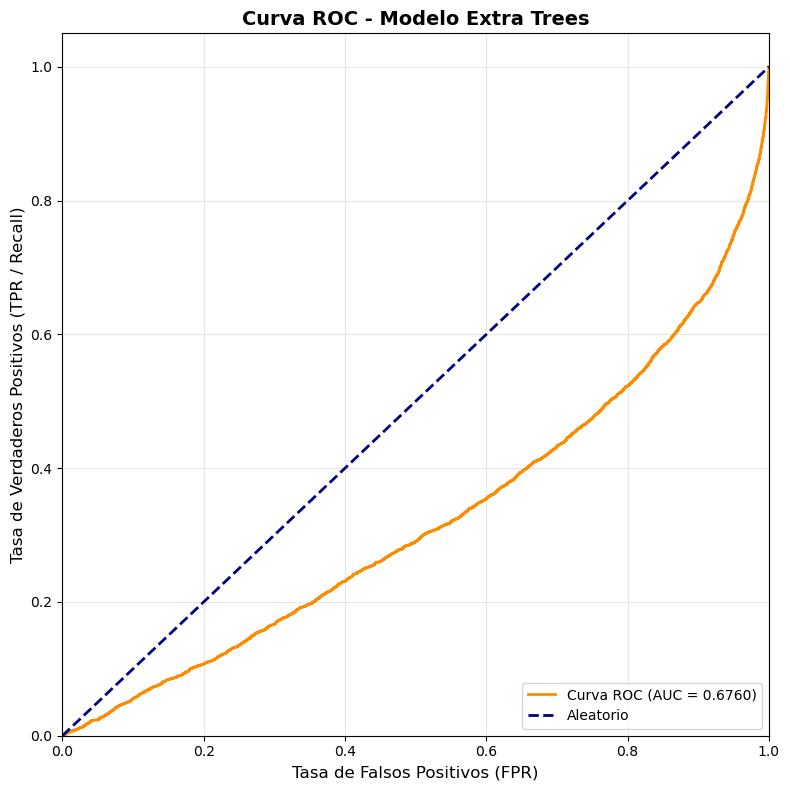

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcula la curva ROC
proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba, pos_label=0)  # pos_label=0 para insatisfechos

# Calcula el AUC
auc_value = roc_auc_score(y_test, proba)

# Crear gráfico
fig, ax = plt.subplots(figsize=(8, 8))

# Curva ROC
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_value:.4f})')

# Línea de aleatoriedad (diagonal)
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')

# Título y labels
ax.set_title('Curva ROC - Modelo Extra Trees', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)

# Límites y grid
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)

# Legenda
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

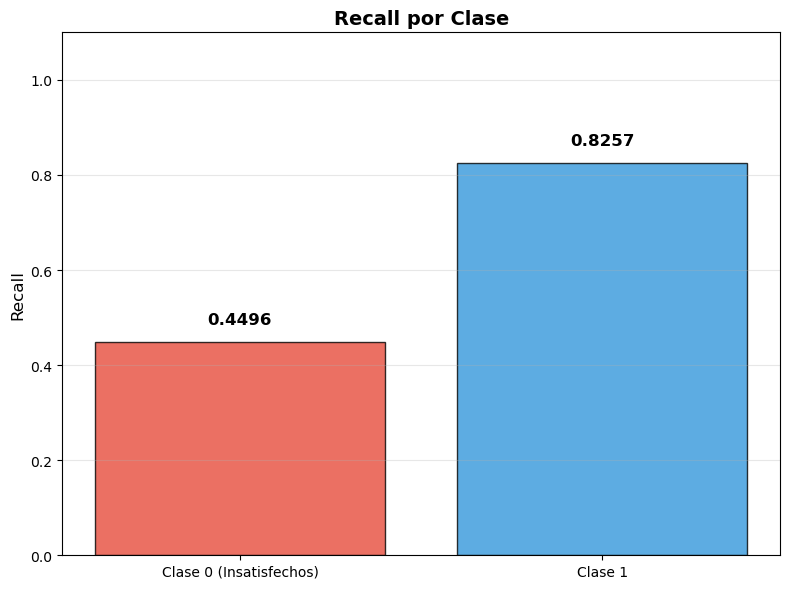

In [ ]:
from sklearn.metrics import recall_score

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
# Calcula recall para cada clase
recall_0 = recall_score(y_test, pred, pos_label=0, zero_division=0)
recall_1 = recall_score(y_test, pred, pos_label=1, zero_division=0)

# Crear Series
recall_values = pd.Series([recall_0, recall_1], index=['Clase 0 (Insatisfechos)', 'Clase 1'])

# Crear gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Barras
colors = ['#e74c3c', '#3498db']  # Rojo para clase 0, azul para clase 1
bars = ax.bar(recall_values.index, recall_values.values, color=colors, edgecolor='black', alpha=0.8)

# Título y labels
ax.set_title('Recall por Clase', fontsize=14, fontweight='bold')
ax.set_ylabel('Recall', fontsize=12)
ax.set_ylim(0, 1.1)  # Recall va de 0 a 1

# Agregar valores en cada barra
for bar, val in zip(bars, recall_values.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
            f'{val:.4f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=12)

# Grid horizontal
ax.yaxis.grid(True, alpha=0.3, linestyle='-')

plt.tight_layout()
plt.show()

In [43]:
import pickle
from sklearn.ensemble import ExtraTreesClassifier

params = {
    'n_estimators': 305,
    'min_samples_split': 42,
    'min_samples_leaf': 26,
    'max_features': 'sqrt',
    'bootstrap': False,
    'class_weight': 'balanced',
    'criterion': 'gini',
    'max_depth': 34 if True else None
}

# Entrena tu modelo (si ya lo tienes entrenado, skipa esto)
model = ExtraTreesClassifier(**params)
model.fit(X_test, y_test)

# Guardar el modelo en un archivo .pkl
with open('modelo_extra_trees.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Modelo guardado correctamente en 'modelo_extra_trees.pkl'")

Modelo guardado correctamente en 'modelo_extra_trees.pkl'


## 11. Resumen ejecutivo

In [22]:
print('=' * 55)
print('RESUMEN STAGE 4 — HIPERPARAMETRIZACIÓN CON OPTUNA')
print('=' * 55)
print(df_optuna.drop(columns=[]).to_string(index=False))
print()
print(f'→ Modelo ganador: {ganador["Modelo"]}')
print(f'  F1(cls 0) val : {ganador["F1(cls 0)"]}')
print(f'  F1(cls 0) test: {m_test["f1_0"]:.4f}')
print(f'  AUC-ROC  test : {m_test["auc"]:.4f}')

RESUMEN STAGE 4 — HIPERPARAMETRIZACIÓN CON OPTUNA
                Modelo  F1(cls 0)  Rec(cls 0)  Pre(cls 0)  F1(cls 1)  Rec(cls 1)  Pre(cls 1)  F1 macro  Accuracy  AUC-ROC   Gini
         Random Forest     0.5693      0.6205      0.5259     0.8174      0.7898      0.8470    0.6934    0.7435   0.7635 0.5270
           Extra Trees     0.5692      0.6314      0.5181     0.8127      0.7793      0.8491    0.6909    0.7389   0.7667 0.5335
              LightGBM     0.5640      0.6492      0.4986     0.8000      0.7546      0.8513    0.6820    0.7258   0.7658 0.5316
Hist Gradient Boosting     0.5631      0.6431      0.5008     0.8019      0.7591      0.8499    0.6825    0.7274   0.7645 0.5289
        SGD Classifier     0.5593      0.6708      0.4796     0.7853      0.7265      0.8545    0.6723    0.7113   0.7626 0.5252
   Logistic Regression     0.5574      0.6719      0.4762     0.7827      0.7223      0.8542    0.6701    0.7086   0.7633 0.5265
              CatBoost     0.5499      0.6395  